In [93]:
from setuptools.sandbox import save_path
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


In [94]:
from sklearn.model_selection import train_test_split

#test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#val
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1149, 64)
Val: (288, 64)
Test: (360, 64)


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [96]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

print(X_train.dtype)
print(X_val.dtype)
print(X_test.dtype)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(y_train.dtype)
print(y_val.dtype)
print(y_test.dtype)

torch.float32
torch.float32
torch.float32
torch.int64
torch.int64
torch.int64


In [97]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=True)

In [98]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(64, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MLP()

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

num_epochs = 100
train_losses = []

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for xx, yy in train_loader:
        optimizer.zero_grad()
        outputs = model(xx)
        loss = criterion(outputs, yy)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print("Epoch:", epoch + 1, "\tTrain loss:", avg_loss)

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for xx, yy in val_loader:
            outputs = model(xx)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == yy).sum().item()
            total += yy.size(0)

    val_acc = correct / total
    print("Val Accuracy:", val_acc)

Epoch: 1 	Train loss: 2.0055298142962985
Val Accuracy: 0.7743055555555556
Epoch: 2 	Train loss: 1.4139617284138997
Val Accuracy: 0.8715277777777778
Epoch: 3 	Train loss: 0.9208356009589301
Val Accuracy: 0.8819444444444444
Epoch: 4 	Train loss: 0.6020390573475096
Val Accuracy: 0.90625
Epoch: 5 	Train loss: 0.42347199552588993
Val Accuracy: 0.9305555555555556
Epoch: 6 	Train loss: 0.3204211609231101
Val Accuracy: 0.9444444444444444
Epoch: 7 	Train loss: 0.2556397368510564
Val Accuracy: 0.9513888888888888
Epoch: 8 	Train loss: 0.210610987411605
Val Accuracy: 0.9548611111111112
Epoch: 9 	Train loss: 0.17740190484457546
Val Accuracy: 0.9618055555555556
Epoch: 10 	Train loss: 0.15254516734017265
Val Accuracy: 0.9652777777777778
Epoch: 11 	Train loss: 0.1334320886267556
Val Accuracy: 0.9652777777777778
Epoch: 12 	Train loss: 0.1187706430339151
Val Accuracy: 0.9722222222222222
Epoch: 13 	Train loss: 0.10411076785789596
Val Accuracy: 0.9791666666666666
Epoch: 14 	Train loss: 0.09380937450461918

In [99]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for xx, yy in test_loader:
        outputs = model(xx)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == yy).sum().item()
        total += yy.size(0)

test_acc = correct / total
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9777777777777777


In [100]:
import os

os.makedirs(os.path.join("resource", "models"), exist_ok=True)
save_path = os.path.join("resource", "models", "lab1.pt")
torch.save(model.state_dict(), save_path)

In [101]:
new_model = MLP()
new_model.load_state_dict(torch.load(os.path.join("resource", "models", "lab1.pt")))
new_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for xx, yy in test_loader:
        outputs = new_model(xx)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == yy).sum().item()
        total += yy.size(0)

loaded_test_acc = correct / total
print("Loaded Model Test Accuracy:", loaded_test_acc)

Loaded Model Test Accuracy: 0.9777777777777777


C:\Users\lzyda\AppData\Local\Temp\ipykernel_27908\1478666513.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load(os.path.join("resource"

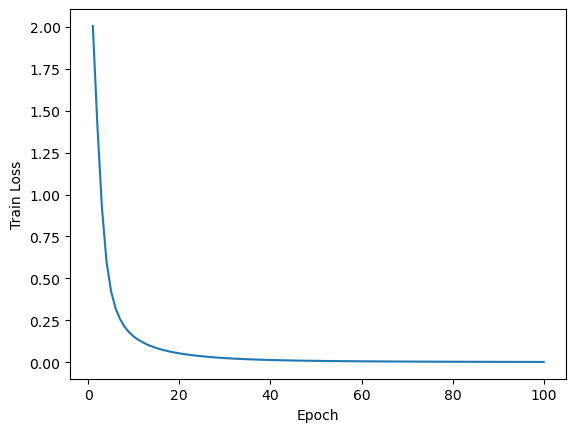

In [102]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.show()